# Telepass Insurance Purchase Prediction

This notebook builds and compares three binary classification models that predict whether a Telepass customer will purchase an insurance policy after receiving a quote.

The three models are:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The goal is to compare their out-of-sample predictive performance and identify which model is most useful for Telepass.

---

## Business context

Telepass is interested in using customer and mobility-related data to strengthen its insurance business.  
In this assignment, the prediction target is whether a customer **purchases** an insurance policy after receiving a quote.

This matters because Telepass can use predicted purchase probabilities to:

- decide whether an offer is worth pushing to a customer
- prioritize customers with higher expected conversion
- evaluate how valuable its data is for the insurance business

---

## Evaluation logic

Because the task is to predict purchase probabilities, the main metric used in this notebook is:

- Log-loss (primary metric)

Secondary metrics:

- ROC-AUC
- Accuracy

To estimate performance honestly, the models are evaluated using 5-fold stratified cross-validation, so the results are based on out-of-sample predictions rather than in-sample fit.

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
np.random.seed(SEED)

## 1. Load the dataset

This notebook expects the Excel file `Telepass.xlsx` to be in the same folder.

In [5]:
!pip install openpyxl

xls = pd.ExcelFile("Telepass.xlsx")
print("Available sheets:", xls.sheet_names)

sheet_name = "Insurance Quotes"
df_raw = pd.read_excel("Telepass.xlsx", sheet_name=sheet_name)

print(f"Loaded '{sheet_name}' dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /opt/local/bin/python3.12 -m pip install --upgrade pip
Available sheets: ['Copyright', 'Data Dictionary', 'Insurance Quotes', 'Transactions']
Loaded 'Insurance Quotes' dataset: 36,173 rows × 40 columns


,client_id,quotation_id,driving_type,car_immatriculation_date,car_brand,car_model,insurance_expires_at,birth_date,gender,county,...,natural_events,theft_fire,kasko,license_revoked,collision,vandalism,key_loss,price_sale,price_full,discount_percent
0,23789,3649,more_than_26,2011-07-20,FORD,C-MAX,2020-06-12,NaN,NaN,FC,...,NaN,22.70,NaN,NaN,121.83,NaN,NaN,325.48,325.48,0.000000
1,10133,28552,more_than_26,2007-03-01,FIAT - INNOCENTI,FIAT CROMA,2020-01-22,NaN,NaN,MS,...,NaN,22.70,NaN,NaN,89.99,NaN,NaN,271.25,306.80,0.115874
2,20785,31958,more_than_26,2017-08-30,NISSAN,NISSAN QASHQAI,2020-10-02,1992-09-22 00:00:00,M,SA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,640.84,684.01,0.063113
3,33892,27614,more_than_26,2017-07-25,FIAT - INNOCENTI,FIAT PANDA,2020-07-25,1996-02-09 00:00:00,M,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2185.38,2204.87,0.008840
4,34153,1529,more_than_26,2006-12-19,FIAT - INNOCENTI,FIAT PUNTO,2020-10-13,2000-01-08 00:00:00,M,CN,...,NaN,24.34,NaN,NaN,156.11,NaN,NaN,207.68,231.20,0.101730


## 2. Inspect the data

First, I check the columns, data types, missing values, and target balance.

In [6]:
print("Columns:")
print(df_raw.columns.tolist())

print("\nData types:")
print(df_raw.dtypes)

print("\nMissing values:")
print(df_raw.isnull().sum())

Columns:
['client_id', 'quotation_id', 'driving_type', 'car_immatriculation_date', 'car_brand', 'car_model', 'insurance_expires_at', 'birth_date', 'gender', 'county', 'base_subscription', 'base_type', 'pay_subscription', 'pay_cancellation', 'premium_subscription', 'premium_cancellation', 'operating_system', 'policy_quoted_at', 'broker_id', 'issued', 'guarantees_purchased', 'guarantees_available', 'roadside_assistance', 'driver_injury', 'basic_coverage', 'legal_protection', 'waive_right_compensation', 'uninsured_vehicles', 'protected_bonus', 'windows', 'natural_events', 'theft_fire', 'kasko', 'license_revoked', 'collision', 'vandalism', 'key_loss', 'price_sale', 'price_full', 'discount_percent']

Data types:
client_id                            int64
quotation_id                         int64
driving_type                        object
car_immatriculation_date    datetime64[ns]
car_brand                           object
car_model                           object
insurance_expires_at     

In [8]:
# Set the correct binary target manually
TARGET = "issued"

print("Target column:", TARGET)
print("\nTarget distribution:")
print(df_raw[TARGET].value_counts(dropna=False))

# Define X and y
y = df_raw[TARGET]
X = df_raw.drop(columns=[TARGET])

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

Target column: issued

Target distribution:
issued
False    26059
True     10114
Name: count, dtype: int64

Feature matrix shape: (36173, 39)
Target shape: (36173,)


## 3. Preprocessing

### Modeling choices

Most available variables are included in the models, but non-predictive ID columns are removed and date variables are transformed into numeric features.

Preprocessing steps:
- separate features X and target y
- remove ID columns (client_id, quotation_id) because they do not carry predictive meaning
- transform date columns into numeric parts (year, month, day)
- label-encode categorical variables
- impute missing numeric values using column medians
- standardize features for logistic regression
- keep the encoded but unscaled feature matrix for tree-based models

Why these choices?

- ID columns are dropped because they identify observations but should not help prediction in a meaningful way.
- Date columns cannot be used directly in most models in this raw format, so they are converted into usable numeric components.
- Logistic regression depends on scale, especially with regularization.
- Decision trees and random forests do not require scaling.
- Keeping most variables is reasonable here because the task is prediction, not causal estimation.

In [14]:
df = df_raw.copy()

# Define target and features
y = df[TARGET].copy()
X = df.drop(columns=[TARGET]).copy()

# Drop columns that should not be used for prediction
# IDs + likely leakage / post-outcome variables
drop_cols = [
    "client_id",
    "quotation_id",
    "guarantees_purchased",   # often only meaningful after purchase
    "price_sale",             # realized sale price can leak issuance
    "price_full",             # pricing outcome-related
    "discount_percent"        # derived from pricing outcome
]

X = X.drop(columns=[c for c in drop_cols if c in X.columns])

# Convert date columns into numeric features
date_cols = X.select_dtypes(include=["datetime64[ns]"]).columns

for col in date_cols:
    X[col + "_year"] = X[col].dt.year
    X[col + "_month"] = X[col].dt.month
    X[col + "_day"] = X[col].dt.day

X = X.drop(columns=date_cols)

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder, StandardScaler

cat_cols = X.select_dtypes(include=["object", "category"]).columns
encoders = {}

for col in cat_cols:
    X[col] = X[col].astype(str)
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

# Handle missing values
X = X.fillna(X.median(numeric_only=True))

# Scale for Logistic Regression
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

feature_names = X.columns.tolist()

print("Final X shape:", X.shape)
print("\nDropped columns:")
print([c for c in drop_cols if c in df_raw.columns])

print("\nTarget distribution:")
print(pd.Series(y).value_counts(normalize=True))

Final X shape: (36173, 45)

Dropped columns:
['client_id', 'quotation_id', 'guarantees_purchased', 'price_sale', 'price_full', 'discount_percent']

Target distribution:
issued
False    0.720399
True     0.279601
Name: proportion, dtype: float64


## 4. Cross-validation setup

I use **5-fold stratified cross-validation** so that:

- each observation is used in testing exactly once
- class balance is preserved across folds
- performance reflects out-of-sample accuracy

The primary metric is **log-loss**, because Telepass needs well-calibrated probabilities, not only class predictions.

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Cross-validation setup
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = ["neg_log_loss", "roc_auc", "accuracy"]

def cv_summary(model, Xmat, y, label):
    res = cross_validate(
        model, Xmat, y,
        cv=CV,
        scoring=SCORING,
        return_train_score=False,
        n_jobs=-1
    )

    ll = -res["test_neg_log_loss"]
    auc = res["test_roc_auc"]
    acc = res["test_accuracy"]

    summary = {
        "Model": label,
        "Log-Loss Mean": ll.mean(),
        "Log-Loss SD": ll.std(),
        "ROC-AUC Mean": auc.mean(),
        "ROC-AUC SD": auc.std(),
        "Accuracy Mean": acc.mean(),
        "Accuracy SD": acc.std()
    }

    return summary, res

# Model 1 Logistic Regression

## Approach

For logistic regression, I used all available features.

Preprocessing choices:
- categorical features were label-encoded
- numeric features were standardized
- missing values were imputed

Configuration:
- `solver='lbfgs'`
- `C=1.0`
- `max_iter=1000`

### Why this model?
Logistic regression is a strong baseline for a binary purchase prediction task because it directly outputs probabilities. It is also easy to explain and less prone to overfitting than more flexible models when the signal is mostly additive.

In [16]:
lr = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    C=1.0,
    random_state=SEED
)

lr_summary, lr_cv = cv_summary(lr, X_scaled, y, "Logistic Regression")
pd.DataFrame([lr_summary]).round(4)

,Model,Log-Loss Mean,Log-Loss SD,ROC-AUC Mean,ROC-AUC SD,Accuracy Mean,Accuracy SD
0,Logistic Regression,0.5609,0.0012,0.6524,0.0028,0.7178,0.0017


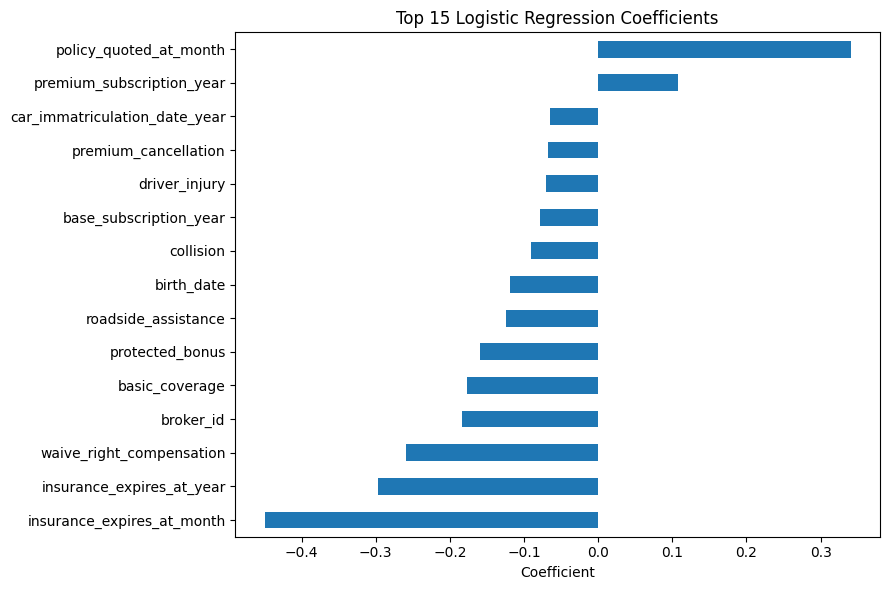

In [18]:
# Fit once on full data for coefficient inspection
lr.fit(X_scaled, y)
lr_coef = pd.Series(lr.coef_[0], index=feature_names).sort_values()

# Show only the strongest coefficients
top_n = 15
top_features = lr_coef.abs().sort_values(ascending=False).head(top_n).index
top_coef = lr_coef.loc[top_features].sort_values()

plt.figure(figsize=(9, 6))
top_coef.plot(kind="barh")
plt.title(f"Top {top_n} Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

### Logistic Regression interpretation

This model gives:
- direct probability estimates
- a clear view of variable direction and relative importance through coefficients

Its main limitation is that it assumes a mostly linear decision boundary unless interaction terms or non-linear transformations are added manually.

# Model 2 Decision Tree

## Approach

The decision tree uses the same preprocessed feature set as the logistic regression, excluding identifier columns and potential leakage variables.

Preprocessing choices:
- no scaling
- encoded categorical variables
- imputed missing values

Main tuning decision:
- choose `max_depth` using cross-validated log-loss

Fixed settings:
- `min_samples_leaf=20`
- `class_weight='balanced'`

### Why this model?
A decision tree can capture non-linear rules and threshold effects. It is highly interpretable, but can overfit quickly if allowed to grow too deep.

In [19]:
depth_grid = [3, 4, 5, 6, 8, None]
dt_depth_results = []

best_dt_depth = None
best_dt_ll = np.inf

for depth in depth_grid:
    dt_tmp = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=SEED
    )
    ll_scores = -cross_val_score(
        dt_tmp, X, y,
        cv=CV,
        scoring="neg_log_loss",
        n_jobs=-1
    )
    mean_ll = ll_scores.mean()
    dt_depth_results.append({"max_depth": depth, "cv_log_loss": mean_ll})

    if mean_ll < best_dt_ll:
        best_dt_ll = mean_ll
        best_dt_depth = depth

pd.DataFrame(dt_depth_results)

,max_depth,cv_log_loss
0,3.0,0.653922
1,4.0,0.650098
2,5.0,0.647737
3,6.0,0.650996
4,8.0,0.688345
5,NaN,1.505462


In [20]:
dt = DecisionTreeClassifier(
    max_depth=best_dt_depth,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=SEED
)

dt_summary, dt_cv = cv_summary(dt, X, y, f"Decision Tree (depth={best_dt_depth})")
pd.DataFrame([dt_summary]).round(4)

,Model,Log-Loss Mean,Log-Loss SD,ROC-AUC Mean,ROC-AUC SD,Accuracy Mean,Accuracy SD
0,Decision Tree (depth=5),0.6477,0.0027,0.6391,0.0045,0.4933,0.027


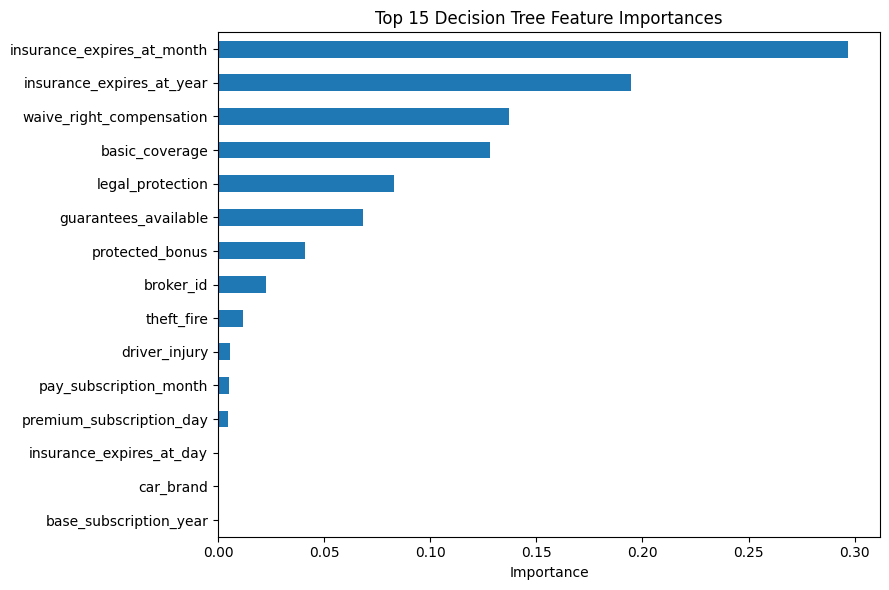

In [22]:
# Fit on full data for feature importance
dt.fit(X, y)
dt_imp = pd.Series(dt.feature_importances_, index=feature_names)

# Keep only top features
top_n = 15
top_features = dt_imp.sort_values(ascending=False).head(top_n).index
top_imp = dt_imp.loc[top_features].sort_values()

plt.figure(figsize=(9, 6))
top_imp.plot(kind="barh")
plt.title(f"Top {top_n} Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Decision Tree interpretation

The decision tree is easy to interpret because it produces clear decision rules. However, its probability estimates are stepwise and less smooth, which makes them less "well-calibrated" compared to logistic regression.

The feature importance results show that timing-related variables, especially insurance expiration (month and year), are the most influential. Some coverage-related features also contribute, but with smaller importance.

A fully grown tree (no depth limit) performed significantly worse due to overfitting, confirming the importance of controlling tree complexity.

Basically to say in overall, while the decision tree captures some non-linear relationships, its predictive performance is slightly weaker than logistic regression.

# Model 3 Random Forest

## Approach

The random forest uses the same preprocessed feature set as the previous models, excluding identifier columns and potential leakage variables. It combines predictions from many decision trees, which helps reduce overfitting and improve generalization.

Configuration:
- `n_estimators=300`
- `max_depth=10`
- `min_samples_leaf=10`
- `max_features='sqrt'`
- `class_weight='balanced'`

### Why this model?
Random forests reduce the instability of a single tree and can capture non-linear relationships and interactions automatically.

In [23]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

rf_summary, rf_cv = cv_summary(rf, X, y, "Random Forest")
pd.DataFrame([rf_summary]).round(4)

,Model,Log-Loss Mean,Log-Loss SD,ROC-AUC Mean,ROC-AUC SD,Accuracy Mean,Accuracy SD
0,Random Forest,0.6026,0.002,0.7077,0.0035,0.5864,0.0045


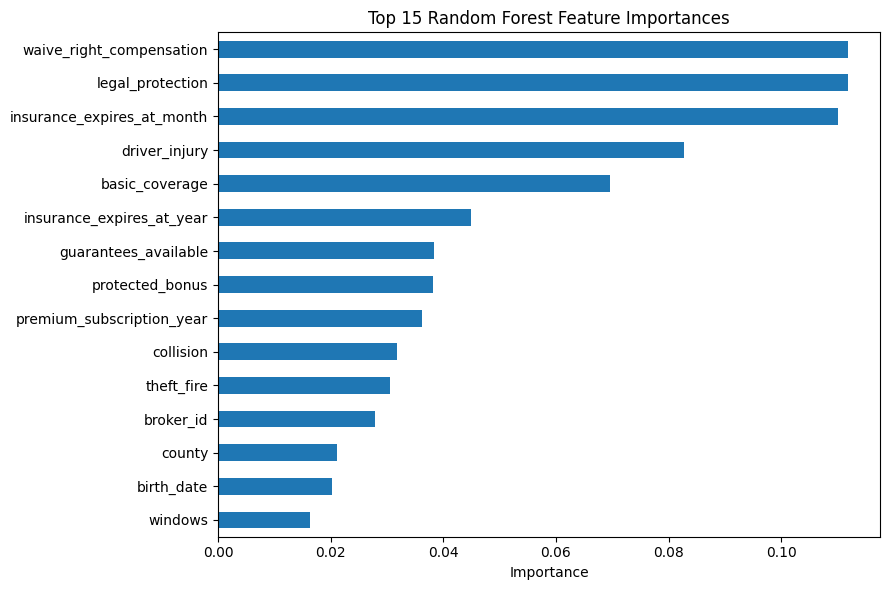

In [25]:
# Fit on full data for feature importance
rf.fit(X, y)
rf_imp = pd.Series(rf.feature_importances_, index=feature_names)

# Show only top features
top_n = 15
top_features = rf_imp.sort_values(ascending=False).head(top_n).index
top_imp = rf_imp.loc[top_features].sort_values()

plt.figure(figsize=(9, 6))
top_imp.plot(kind="barh")
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Random Forest interpretation

The random forest model improves over the decision tree by reducing variance through averaging multiple trees. It achieves the best overall performance among the tested models, particularly in terms of ROC-AUC.

Feature importance analysis again highlights timing variables, such as insurance expiration, and coverage-related features as the most influential. This confirms the patterns observed in the previous models, but the random forest captures these relationships in a more flexible and robust way.

The main drawback is reduced interpretability compared to logistic regression, as the model is an ensemble of many trees and does not provide simple coefficients or decision rules.

# 5. Model comparison

Now I compare all three models using the same out-of-sample cross-validation framework.

The primary evaluation metric is log-loss, because Telepass needs reliable predicted probabilities. However, I also consider ROC-AUC, which reflects how well the model ranks customers by purchase likelihood, and accuracy as a secondary metric.

From the results:

- Logistic regression achieves the lowest log-loss, meaning it produces the best calibrated probabilities.
- Random forest achieves the highest ROC-AUC, meaning it is best at ranking customers correctly.
- Decision tree performs worst across all metrics, likely due to overfitting and instability.

These results suggest that while logistic regression is strong for probability estimation, random forest captures more complex patterns in the data that improve classification performance.

In [28]:
summary_df = pd.DataFrame([lr_summary, dt_summary, rf_summary])
summary_df = summary_df.sort_values("Log-Loss Mean").reset_index(drop=True)
summary_df.round(4)

,Model,Log-Loss Mean,Log-Loss SD,ROC-AUC Mean,ROC-AUC SD,Accuracy Mean,Accuracy SD
0,Logistic Regression,0.5609,0.0012,0.6524,0.0028,0.7178,0.0017
1,Random Forest,0.6026,0.0020,0.7077,0.0035,0.5864,0.0045
2,Decision Tree (depth=5),0.6477,0.0027,0.6391,0.0045,0.4933,0.0270


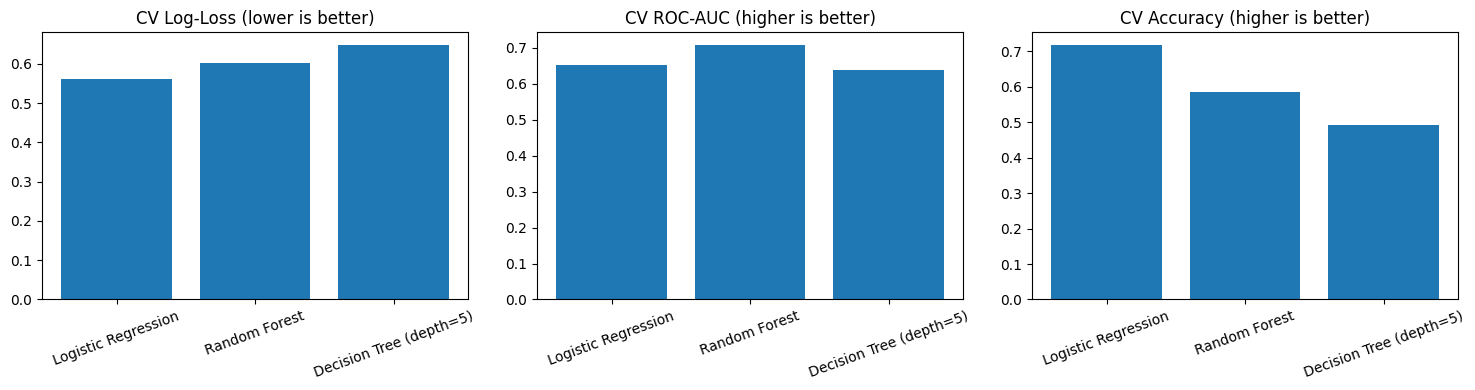

In [29]:
# Simple visualization of the comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(summary_df["Model"], summary_df["Log-Loss Mean"])
axes[0].set_title("CV Log-Loss (lower is better)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(summary_df["Model"], summary_df["ROC-AUC Mean"])
axes[1].set_title("CV ROC-AUC (higher is better)")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(summary_df["Model"], summary_df["Accuracy Mean"])
axes[2].set_title("CV Accuracy (higher is better)")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 6. What do the results mean?

## Logistic Regression
Strengths:
- best-calibrated probabilities (lowest log-loss)
- simple and easy to interpret
- strong out-of-sample baseline

Weaknesses:
- may miss complex non-linear patterns
- interaction effects must be engineered manually

## Decision Tree
Strengths:
- very interpretable
- captures threshold effects

Weaknesses:
- unstable
- weaker probability calibration
- more prone to overfitting

## Random Forest
Strengths:
- captures non-linearities and interactions
- more stable than a single tree
- best at ranking customers (highest ROC-AUC)

Weaknesses:
- less interpretable
- probability estimates can still be less calibrated than logistic regression

Overall, the results show a trade-off between interpretability and predictive performance. Logistic regression gives better probability estimates, while random forest is better at identifying which customers are more likely to purchase.

## 7. Final conclusion
- Logistic regression achieves the lowest log-loss, meaning it produces the best calibrated probabilities.
- Random forest achieves the highest ROC-AUC, meaning it is better at ranking customers by purchase likelihood.
- Since the main business goal is to identify and prioritize customers for targeting, ranking performance is more important than perfectly calibrated probabilities.
- Therefore, the random forest is the preferred model in this case.
- This suggests that customer purchase behavior is influenced by more complex and non-linear relationships, which are better captured by the random forest.

## Business implication for Telepass
- The random forest model can be used to score customers based on their predicted likelihood of purchase.
- It can support decisions such as:
- which insurance offers to push
- which customers are most worth targeting
- whether existing customer data contains useful business signals
- A practical next step is to combine predicted purchase probability with expected profit and outreach cost, so that customers are targeted based on expected value rather than probability alone.